In [1]:
ls ../data/filtration

190515/  190814/  190816/  190925/  190926/


In [19]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os.path

work = "190926"
encoding = "utf-16"
columns = ["Time", "Signal"] # Time is in minute

In [20]:
data_dir = "../data/filtration"
samples = {
    "190515":["LP", "PR", "LR", "LPR",],
    "190814":["C","LPR","LPRC"],
    "190816":["L","P","R","LR","PR","LP","LPR"],
    "190925":["L", "P", "R", "LR", "PR", "LP", "LPR"],
    "190926":["C", "LPR", "LPRC"],
}[work]

labels = {
    "190515":{
        "PR": "PABPC1+A25",
        "LP": "LARP1+PABPC1",
        "LR": "LARP1+A25",
        "LPR":"LARP1+PABPC1+A25",},
    
    "190814":{
        "C": "CCR4-CAF1 (C)",
        "LPR": "LARP1+PABPC1+A25 (LPR)",
        "LPRC": "LPR+C"},
    
    "190816":{
        "L": "LARP1 (L)",
        "P": "PABPC1 (P)",
        "R": "A25 (R)",
        "LR": "L+R",
        "PR": "P+R",
        "LP": "L+P",
        "LPR": "L+P+R"},
    
    "190925":{
        "L": "LARP1 (L)",
        "P": "PABPC1 (P)",
        "R": "A25 (R)",
        "LR": "L+R",
        "PR": "P+R",
        "LP": "L+P",
        "LPR": "L+P+R"},
    
    "190926":{
        "C": "CCR4-CAF1 (C)",
        "LPR": "LARP1+PABPC1+A25 (LPR)",
        "LPRC": "LPR+C"},
}[work]

readouts = {
    "190814":["260","280"],
}.get(work, ["260","280"])

# vlines = {
#     "190515": {}
#         "PR": [7.518]
# }[work]

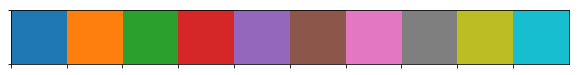

In [21]:
colors = {
    "190515": sns.xkcd_palette(["grey", "black", "dark peach", "vermillion"]),
}.get(work, plt.rcParams['axes.prop_cycle'].by_key()['color'])

# colors = sns.xkcd_palette(colors)
sns.palplot(colors)
plt.show()

260/280 ratio  
protein: 0.57  
RNA: 2.0

Multiple subplots

C
LPR
LPRC
../plots/gel_filtration_190926_mini.pdf


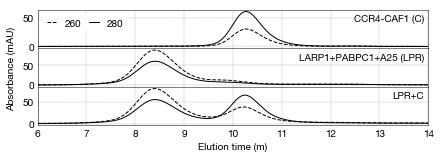

In [22]:
### Multiple subplots for every sample
savefig = True
minifig = True
figsize = [14, 0.5 + 1.25 * len(samples)]
styles = ["barricade"]
   
linestyles = dict(zip(readouts, ["--","-",":"]))
pri_ro = 280 # primary readout for pinpointing the peak

if minifig:
    styles.append("mini")
    figsize = list(map(lambda x:x/2, figsize))

with plt.style.context(styles):
    fig, axes = plt.subplots(nrows=len(samples), sharex=True, sharey=False, figsize=figsize,
                             gridspec_kw={'hspace': 0, 'wspace': 0})
    for si, smp in enumerate(samples):
        ax = axes[si]
        for ro in readouts: 
            fpath = os.path.join(data_dir, work, smp+"-"+str(ro)+".CSV")
            df = pd.read_table(fpath, header=None, names=columns, encoding=encoding)

            ls = linestyles[ro]
            ax.plot(df["Time"], df["Signal"], color="black", ls=ls, label=ro)

#         ax.set_ylim([0,130])
        ax.text(x=0.99, y=0.7, s=labels[smp], transform=ax.transAxes, ha="right")
    
        if si == 0: ax.legend(loc="upper left", ncol=len(readouts), columnspacing=0.8)
                
        ax.grid(True)
        print(smp)
    
    plt.xlim([6,14])
    
    ## Draw a big axes for the common {x,y}label
    fig.add_subplot(111, frameon=False)
    plt.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    plt.xlabel("Elution time (m)")
    plt.ylabel("Absorbance (mAU)")
    fname_adduct=""
    if minifig is True: fname_adduct += "_mini"
    if savefig is True:
        outfigpath = "../plots/gel_filtration_{}{}.pdf".format(work, fname_adduct)
        print( outfigpath )
        plt.savefig(outfigpath, bbox_inches="tight", dpi=300)
    plt.show()



Multiple subplots with reference lines

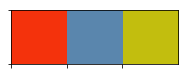

In [14]:
reference_samples = samples[:3]
refsmp_colors = sns.xkcd_palette(["vermillion", "dusty blue", "puke yellow"])
sns.palplot(refsmp_colors)
plt.show()
rc = dict(zip(reference_samples, refsmp_colors))

vmarks = {
    "LR": ["L", "R"],
    "LP": ["L", "P"],
    "PR": ["P", "R"],
    "LPR": ["L", "P", "R"]
}

refpos = {refsmp:None for refsmp in reference_samples} # Assumes all data have the same number of datapoints

L
P
R
LR
PR
LP
LPR
../plots/gel_filtration_190925_w_vmarks__mini.pdf


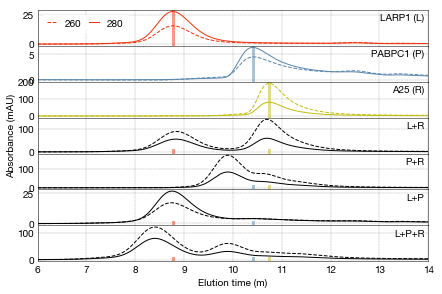

In [18]:
### Multiple subplots for every sample
savefig = True
minifig = True
figsize = [14, 0.5 + 1.25 * len(samples)]
styles = ["barricade"]

linestyles = dict(zip(readouts, ["--","-",":"]))
pri_ro = readouts[1] # primary readout for pinpointing the peak

if minifig:
    styles.append("mini")
    figsize = list(map(lambda x:x/2, figsize))

with plt.style.context(styles):
    fig, axes = plt.subplots(nrows=len(samples), sharex=True, sharey=False, figsize=figsize,
                             gridspec_kw={'hspace': 0, 'wspace': 0})
    for si, smp in enumerate(samples):
        ax = axes[si]
        for ro in readouts: 
            fpath = os.path.join(data_dir, work, smp+"-"+str(ro)+".CSV")
            df = pd.read_table(fpath, header=None, names=columns, encoding=encoding)
            
            ls = linestyles[ro]
            if smp in reference_samples:
                ax.plot(df["Time"], df["Signal"], color=rc[smp], ls=ls, label=ro)
                
                if ro == pri_ro:
                    refpos[smp] = df["Signal"].idxmax()
                    ax.axvline(x=df.loc[refpos[smp], "Time"], color=rc[smp], lw=3, alpha=0.5)
            
            else: 
                ax.plot(df["Time"], df["Signal"], color="black", ls=ls, label=ro)
                
                if ro == pri_ro:
                    for vm in vmarks[smp]:
                        ax.axvline(x=df.loc[refpos[vm], "Time"], ymax=0.1, color=rc[vm], lw=3, alpha=0.5)
                    

#         ax.set_ylim([0,130])
        ax.text(x=0.99, y=0.7, s=labels[smp], transform=ax.transAxes, ha="right")
    
        if si == 0: ax.legend(loc="upper left", ncol=len(readouts), columnspacing=0.8)
                
        ax.grid(True)
        print(smp)
    
    plt.xlim([6,14])
    
    ## Draw a big axes for the common {x,y}label
    fig.add_subplot(111, frameon=False)
    plt.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    plt.xlabel("Elution time (m)")
    plt.ylabel("Absorbance (mAU)")
    fname_adduct=""
    if minifig is True: fname_adduct += "_mini"
    if savefig is True:
        outfigpath = "../plots/gel_filtration_{}_w_vmarks_{}.pdf".format(work, fname_adduct)
        print( outfigpath )
        plt.savefig(outfigpath, bbox_inches="tight", dpi=300)
    plt.show()




Separate figures

C


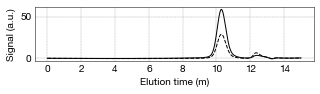

LPR


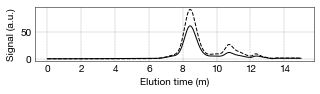

LPRC


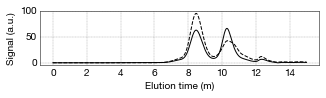

In [74]:
### Assumes there are A280 and A260 measurements
savefig = False
minifig = True
figsize = (10,2.4) if minifig is not True else (5,1)
styles = ["barricade"]
   
linestyles = dict(zip(readouts, ["--","-",":"]))
pri_ro = 280 # primary readout for pinpointing the peak

if minifig: styles.append("mini")
with plt.style.context(styles):
    for si, smp in enumerate(samples):
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111)
        for ro in readouts: 
            fpath = os.path.join(data_dir, work, smp+"-"+str(ro)+".CSV")
            df = pd.read_table(fpath, header=None, names=columns, encoding=encoding)

            ls = linestyles[ro]
            ax.plot(df["Time"], df["Signal"], color="black", ls=ls)
            
#             if str(ro) == pri_ro:
#             vlines = [df.set_index("Time").idxmax().values[0]]
#             for vline in vlines:
#                 ax.axvline(x=vline, lw=2, color="black", alpha=0.3)
                
#                 # Signal intensity at the peak
#                 vsig = df.set_index("Time").loc[vline].values[0]
#                 ax.text(x=vline*1.02, y=vsig, s="%.3f"%(vsig), va="top")
                
#         ax.text(x=vline, y=ax.get_ylim()[1]*1.07, s="%.3f m"%(vline), ha="center")
                
        ax.grid(True)
#         ax.set_xlim([5,15])
        ax.set_xlabel("Elution time (m)")
        ax.set_ylabel("Signal (a.u.)")
#         ax.text(x=0.99, y=0.8, s=label[smp], ha="right", transform=ax.transAxes)
        print(smp)
        fname_adduct=""
        if minifig is True: fname_adduct += "_mini"
        if savefig is True:
            outfigpath = "../plots/gel_filtration_{}-{}{}.pdf".format(work, smp, fname_adduct)
            print( outfigpath )
            plt.savefig(outfigpath, bbox_inches="tight", dpi=300)
        plt.show()


Combined plots

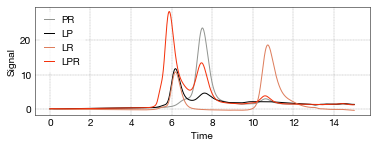

In [160]:
### Assumes there are A280 and A260 measurements
minifig = True
figsize = (12,4) if minifig is not True else (6,2)
styles = ["barricade"]
if minifig: styles.append("mini")
with plt.style.context(styles):
    for wl in [280, 260]:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111)
        for si, smp in enumerate(samples):
            fpath = os.path.join(data_dir, work, smp+str(wl)+".CSV")
            df = pd.read_table(fpath, header=None, names=columns, encoding=encoding)
            sns.lineplot(x="Time", y="Signal", data=df, color=colors[si], label=smp, ax=ax)
        ax.grid(True)
        ax.legend(loc="upper left")
        plt.show()
        break